# `frust_by_T.ipynb`: frustration by temperature

In [1]:
import jax
from jax import numpy as jnp
import matplotlib
from matplotlib import patches as mpatches
from matplotlib import pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from pathlib import Path
from scipy.stats import ttest_ind

from utils.energies import *
from utils.modelIO import *

initialize

In [2]:
GIDS_PATH = Path('data/eml/eml_gene_ids.csv')
BIO_GRN_PATH = Path('data/eml/eml_fate_network.npy')
RAND_GRN_PATH = Path('results/eml/random_networks.npy')
BIO_SIM_PATH = Path('results/eml/bio_T_coarse/')
RAND_SIM_PATH = Path('results/eml/rand_T_coarse/')
FIG_SAVE_PATH = Path('figs/eml/')

bio_grn, gids, N = load_grn(BIO_GRN_PATH, GIDS_PATH)
rgrns = jnp.load(RAND_GRN_PATH)[:1000]
temperatures = jnp.linspace(0.0, 5.0, 11)

load final states

In [3]:
def load_bio_T(T):
    path = BIO_SIM_PATH.joinpath('bio_cT_{:02}_xs.npy'.format((10*T).astype(int)))
    return jnp.load(path)[:, -1]
bio_xs = jnp.array([load_bio_T(T) for T in temperatures])

def load_rand_T(T):
    path = RAND_SIM_PATH.joinpath('rand_cT_{:02}_xs.npy'.format((10*T).astype(int)))
    return jnp.load(path)[:, -1]
rand_xs = jnp.array([load_rand_T(T) for T in temperatures])

vmap function for biological GRN

In [4]:
def bio_frust_instance(grn_state):
    return get_pct_frustration(bio_grn, grn_state, N)
bio_frust_vmap = jax.vmap(jax.vmap(bio_frust_instance))
bio_frust = bio_frust_vmap(bio_xs)

vmap function for random networks

In [5]:
def rand_frust_instance(rand_pair):
    rgrn, grn_state = rand_pair
    return get_pct_frustration(rgrn, grn_state, N)
rand_frust_vmap = jax.vmap(rand_frust_instance)
rand_frust = jnp.array([rand_frust_vmap((rgrns, xs)) for xs in rand_xs])

make violin plots

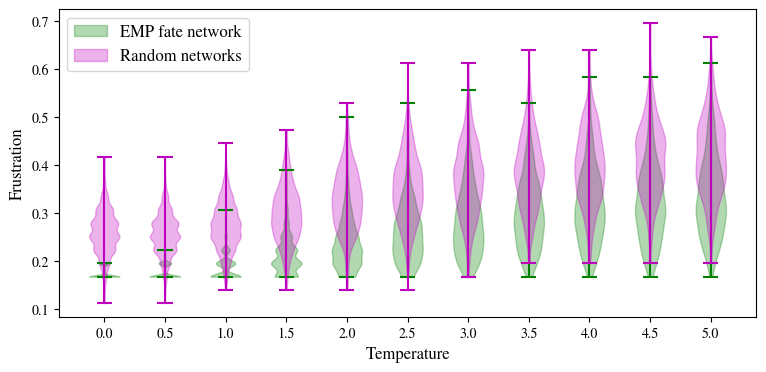

In [6]:
def set_axis_style(ax, labels):
    ax.set_xticks(jnp.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Temperature', fontsize=12)

labels = []
def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))

fig, ax = plt.subplots(figsize=(9, 4))
bio_violin = ax.violinplot(bio_frust.T)
rand_violin = ax.violinplot(rand_frust.T)

for pc in bio_violin['bodies']:
    pc.set_color('g')
bio_violin['cmaxes'].set_color('g')
bio_violin['cmins'].set_color('g')
bio_violin['cbars'].set_color('g')

for pc in rand_violin['bodies']:
    pc.set_color('m')
rand_violin['cmaxes'].set_color('m')
rand_violin['cmins'].set_color('m')
rand_violin['cbars'].set_color('m')

ax.set_ylabel('Frustration', fontsize=12)
add_label(bio_violin, 'EMP fate network')
add_label(rand_violin, 'Random networks')
plt.legend(*zip(*labels), fontsize=12)
set_axis_style(ax, temperatures)
plt.savefig(FIG_SAVE_PATH.joinpath('frust_by_T.pdf'), bbox_inches='tight')

In [7]:
ttest_results = [ttest_ind(bio_frust[i], rand_frust[i], equal_var=False) for i in range(len(temperatures))]

In [8]:
ttest_results

[TtestResult(statistic=np.float64(-58.2970791925597), pvalue=np.float64(0.0), df=np.float64(1142.8298419344821)),
 TtestResult(statistic=np.float64(-55.70936881807208), pvalue=np.float64(0.0), df=np.float64(1212.4294503081123)),
 TtestResult(statistic=np.float64(-47.76166142693507), pvalue=np.float64(3.186173962954126e-301), df=np.float64(1468.432269121569)),
 TtestResult(statistic=np.float64(-38.643369391096655), pvalue=np.float64(8.362192174421224e-236), df=np.float64(1722.9615606850132)),
 TtestResult(statistic=np.float64(-34.33723804713287), pvalue=np.float64(2.317138676070972e-201), df=np.float64(1896.6069481332065)),
 TtestResult(statistic=np.float64(-30.977669524276987), pvalue=np.float64(1.3534806125031545e-171), df=np.float64(1944.1256525753665)),
 TtestResult(statistic=np.float64(-27.784721508096517), pvalue=np.float64(7.169236628992824e-144), df=np.float64(1991.515330184278)),
 TtestResult(statistic=np.float64(-27.12529517140245), pvalue=np.float64(4.5863762929772565e-138), 